# 06 — Soil Features (gSSURGO)

Extract USDA gSSURGO soil properties per hex cell.

**Variables:**

| Feature | Description | Cannabis relevance |
|---|---|---|
| `ph1to1h2o` | Soil pH (1:1 water) | Optimal 6.0–7.0 |
| `awc` | Available water capacity (cm/cm) | Water retention |
| `om` | Organic matter (%) | Nutrient cycling |
| `cec7` | CEC at pH 7 (meq/100g) | Nutrient holding |
| `sandtotal` | Sand % | Drainage |
| `silttotal` | Silt % | Texture |
| `claytotal` | Clay % | Texture / drainage |
| `drainagecl` | Drainage class (ordinal) | Waterlogging risk |

**Source:** USDA Web Soil Survey gSSURGO via Soil Data Access API (SDA)  
No API key required.

**Outputs:**
- `data/raw/ssurgo/` — per-county soil GeoPackages
- `data/processed/soil_features.pkl` — per-cell soil DataFrame

In [1]:
from pathlib import Path
import requests
import json as _json
import numpy as np
import pandas as pd
import geopandas as gpd
from rasterstats import zonal_stats
import matplotlib.pyplot as plt

RAW  = Path('../data/raw')
PROC = Path('../data/processed')
IMG  = Path('../img')
SSURGO_DIR = RAW / 'ssurgo'
SSURGO_DIR.mkdir(exist_ok=True)

TARGET_COUNTIES = ['Humboldt', 'Mendocino', 'Trinity']
STATE_FIPS = '06'   # California

# Drainage class → ordinal score (higher = better drained)
DRAINAGE_ORDER = {
    'Very poorly drained': 1,
    'Poorly drained':      2,
    'Somewhat poorly drained': 3,
    'Moderately well drained': 4,
    'Well drained':        5,
    'Somewhat excessively drained': 6,
    'Excessively drained': 7,
}

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Query Soil Data Access (SDA) for component data

In [2]:
SDA_URL = 'https://sdmdataaccess.nrcs.usda.gov/tabular/post.rest'

# Fetch map unit keys (mukey) and component soil properties
# for all map units intersecting the three counties.
# Uses the chorizon and component tables joined to mapunit.
SOIL_QUERY = """
SELECT
    mu.mukey,
    mu.muname,
    co.cokey,
    co.majcompflag,
    co.comppct_r,
    co.drainagecl,
    ch.hzdept_r,
    ch.hzdepb_r,
    ch.sandtotal_r,
    ch.silttotal_r,
    ch.claytotal_r,
    ch.om_r,
    ch.awc_r,
    ch.cec7_r,
    ch.ph1to1h2o_r
FROM
    legend AS l
    INNER JOIN mapunit AS mu ON mu.lkey = l.lkey
    INNER JOIN component AS co ON co.mukey = mu.mukey
    INNER JOIN chorizon AS ch ON ch.cokey = co.cokey
WHERE
    l.areasymbol IN (SELECT areasymbol FROM sacatalog
                     WHERE areaname LIKE '%Humboldt%'
                        OR areaname LIKE '%Mendocino%'
                        OR areaname LIKE '%Trinity%')
    AND co.majcompflag = 'Yes'
    AND ch.hzdept_r < 30        -- top 30cm (root zone)
ORDER BY mu.mukey, co.comppct_r DESC
"""

cache = SSURGO_DIR / 'sda_components.csv'
if cache.exists():
    comp_df = pd.read_csv(cache)
    print(f'Loaded cached SDA data: {comp_df.shape}')
else:
    print('Querying Soil Data Access...')
    r = requests.post(
        SDA_URL,
        data={'query': SOIL_QUERY, 'format': 'JSON+COLUMNNAME'},
        timeout=120,
    )
    r.raise_for_status()
    result = r.json()
    cols = result['Table'][0]
    rows = result['Table'][1:]
    comp_df = pd.DataFrame(rows, columns=cols)
    comp_df.to_csv(cache, index=False)
    print(f'Fetched {len(comp_df):,} horizon rows → {cache}')

print(comp_df.shape)
comp_df.head(3)

Loaded cached SDA data: (12196, 15)
(12196, 15)


,mukey,muname,cokey,majcompflag,comppct_r,drainagecl,hzdept_r,hzdepb_r,sandtotal_r,silttotal_r,claytotal_r,om_r,awc_r,cec7_r,ph1to1h2o_r
0,447442,"Okoboji silty clay loam, 0 to 1 percent slopes",27374039,Yes,85,Very poorly drained,0,20,11.0,53.0,36.0,9.0,0.22,29.5,6.8
1,447442,"Okoboji silty clay loam, 0 to 1 percent slopes",27374039,Yes,85,Very poorly drained,20,84,12.0,52.0,36.0,6.0,0.22,29.2,7.0
2,447443,"Terril loam, 2 to 6 percent slopes",27374038,Yes,80,Well drained,23,86,46.0,33.0,21.0,2.5,0.18,18.0,6.2


## 2. Aggregate to map unit level

Weight horizon values by thickness; weight components by their coverage percentage.

In [3]:
numeric_cols = ['sandtotal_r', 'silttotal_r', 'claytotal_r',
                'om_r', 'awc_r', 'cec7_r', 'ph1to1h2o_r']

comp_df[numeric_cols + ['hzdept_r', 'hzdepb_r', 'comppct_r']] = (
    comp_df[numeric_cols + ['hzdept_r', 'hzdepb_r', 'comppct_r']]
    .apply(pd.to_numeric, errors='coerce')
)

# Thickness-weighted average per component
comp_df['thickness'] = comp_df['hzdepb_r'] - comp_df['hzdept_r']
comp_df['thickness'] = comp_df['thickness'].clip(lower=0.1)

def wtd_mean(df, val_col, wt_col):
    w = df[wt_col].fillna(0)
    v = df[val_col]
    mask = v.notna() & (w > 0)
    if mask.sum() == 0:
        return np.nan
    return (v[mask] * w[mask]).sum() / w[mask].sum()

# Per-component horizon average (thickness-weighted)
comp_hz = comp_df.groupby('cokey').apply(
    lambda g: pd.Series({col: wtd_mean(g, col, 'thickness') for col in numeric_cols})
).reset_index()

# Add comppct and drainage class (take from first row per cokey)
comp_meta = comp_df.groupby('cokey').agg(
    mukey=('mukey', 'first'),
    comppct_r=('comppct_r', 'first'),
    drainagecl=('drainagecl', 'first'),
).reset_index()
comp_hz = comp_hz.merge(comp_meta, on='cokey')

# Per-map-unit weighted average (component percentage weighted)
mu_soil = comp_hz.groupby('mukey').apply(
    lambda g: pd.Series({
        **{col: wtd_mean(g, col, 'comppct_r') for col in numeric_cols},
        'drainagecl': g.loc[g['comppct_r'].idxmax(), 'drainagecl'],  # dominant component
    })
).reset_index()
mu_soil['mukey'] = mu_soil['mukey'].astype(str)
mu_soil['drainage_score'] = mu_soil['drainagecl'].map(DRAINAGE_ORDER)

print(f'Map units with soil data: {len(mu_soil):,}')
print(mu_soil.describe().round(2))

Map units with soil data: 2,884
       sandtotal_r  silttotal_r  claytotal_r     om_r    awc_r   cec7_r  \
count      2862.00      2862.00      2866.00  2866.00  2869.00  2741.00   
mean         44.37        33.90        21.69     2.79     0.13    20.08   
std          15.96        10.73         8.93     3.75     0.05    13.56   
min           2.68         0.60         0.00     0.00     0.00     0.10   
25%          34.86        27.90        15.96     0.89     0.10    13.06   
50%          41.40        34.89        21.55     1.51     0.13    17.24   
75%          53.86        38.00        26.67     2.96     0.16    22.57   
max          99.00        75.00        63.04    65.00     0.48   134.40   

       ph1to1h2o_r  drainage_score  
count      2860.00         2871.00  
mean          6.69            4.83  
std           1.03            0.95  
min           3.96            1.00  
25%           5.88            5.00  
50%           6.52            5.00  
75%           7.42            5.0

## 3. Download SoilGrids rasters (ISRIC WCS)

SoilGrids 250m — globally consistent, REST accessible, no auth needed.
Averages 0–5cm, 5–15cm, 15–30cm layers into a 0–30cm root-zone composite.

In [4]:
import subprocess

SOILGRIDS_VARS = {
    'ph':   'phh2o',
    'soc':  'soc',
    'sand': 'sand',
    'silt': 'silt',
    'clay': 'clay',
    'cec':  'cec',
}
DEPTHS = ['0-5cm', '5-15cm', '15-30cm']

study_wgs = gpd.read_file(RAW / 'study_area.gpkg').to_crs('EPSG:4326')
b = study_wgs.total_bounds
west, south, east, north = b

soilgrids_tifs = {}

for short_name, sg_var in SOILGRIDS_VARS.items():
    out_utm = SSURGO_DIR / f'{short_name}_utm.tif'
    if out_utm.exists():
        print(f'  {short_name}: cached')
        soilgrids_tifs[short_name] = out_utm
        continue

    depth_tifs = []
    for depth in DEPTHS:
        coverage_id = f'{sg_var}_{depth}_mean'
        out_depth   = SSURGO_DIR / f'{sg_var}_{depth}.tif'
        if not out_depth.exists():
            # WCS 2.0.1 uses SUBSET instead of BBOX, no WIDTH/HEIGHT
            params = {
                'map':          f'/map/{sg_var}.map',
                'SERVICE':      'WCS',
                'VERSION':      '2.0.1',
                'REQUEST':      'GetCoverage',
                'COVERAGEID':   coverage_id,
                'FORMAT':       'image/tiff',
                'SUBSETTINGCRS':'http://www.opengis.net/def/crs/EPSG/0/4326',
                'OUTPUTCRS':    'http://www.opengis.net/def/crs/EPSG/0/4326',
            }
            # SUBSET must be sent as two separate params with the same key
            subset_params = [
                ('SUBSET', f'X({west},{east})'),
                ('SUBSET', f'Y({south},{north})'),
            ]
            print(f'  {coverage_id}...')
            r = requests.get(
                'https://maps.isric.org/mapserv',
                params=list(params.items()) + subset_params,
                timeout=120,
            )
            r.raise_for_status()
            out_depth.write_bytes(r.content)
        depth_tifs.append(str(out_depth))

    # Average the three depth layers
    avg_wgs = SSURGO_DIR / f'{short_name}_avg_wgs.tif'
    subprocess.run([
        'gdal_calc.py',
        '-A', depth_tifs[0], '-B', depth_tifs[1], '-C', depth_tifs[2],
        f'--outfile={avg_wgs}',
        '--calc=(A+B+C)/3',
        '--NoDataValue=-9999', '--quiet',
    ], check=True)

    study_utm = gpd.read_file(RAW / 'study_area.gpkg')
    bu = study_utm.total_bounds
    subprocess.run([
        'gdalwarp',
        '-t_srs', 'EPSG:32610',
        '-te', str(bu[0]), str(bu[1]), str(bu[2]), str(bu[3]),
        '-tr', '250', '250',
        '-r',  'bilinear',
        '-co', 'COMPRESS=LZW',
        str(avg_wgs), str(out_utm),
    ], check=True, capture_output=True)

    soilgrids_tifs[short_name] = out_utm
    print(f'  {short_name}: done')

print('SoilGrids rasters ready:', list(soilgrids_tifs.keys()))

  phh2o_0-5cm_mean...
  phh2o_5-15cm_mean...
  phh2o_15-30cm_mean...
  ph: done
  soc_0-5cm_mean...
  soc_5-15cm_mean...
  soc_15-30cm_mean...
  soc: done
  sand_0-5cm_mean...
  sand_5-15cm_mean...
  sand_15-30cm_mean...
  sand: done
  silt_0-5cm_mean...
  silt_5-15cm_mean...
  silt_15-30cm_mean...
  silt: done
  clay_0-5cm_mean...
  clay_5-15cm_mean...
  clay_15-30cm_mean...
  clay: done
  cec_0-5cm_mean...
  cec_5-15cm_mean...
  cec_15-30cm_mean...
  cec: done
SoilGrids rasters ready: ['ph', 'soc', 'sand', 'silt', 'clay', 'cec']


## 4. Spatial join to hex grid

In [5]:
hex_grid = gpd.read_file(RAW / 'hex_grid.gpkg')
frames   = [hex_grid[['cell_id']].reset_index(drop=True)]

for var, raster_path in soilgrids_tifs.items():
    print(f'  {var}...')
    stats = zonal_stats(
        hex_grid, str(raster_path),
        stats=['mean'], nodata=-9999, all_touched=False,
    )
    df = pd.DataFrame(stats).rename(columns={'mean': var})
    frames.append(df)

soil_feats = pd.concat(frames, axis=1)
n_valid = soil_feats['ph'].notna().sum()
print(f'Cells with soil data: {n_valid:,} / {len(soil_feats):,}')
print(soil_feats.describe().round(2))

  ph...
  soc...
  sand...
  silt...
  clay...
  cec...
Cells with soil data: 8,923 / 8,923
            ph      soc     sand     silt     clay      cec
count  8923.00  8923.00  8923.00  8923.00  8923.00  8923.00
mean     51.68   527.36   351.23   337.13   207.72   194.56
std      17.05   247.36   137.78   118.76    79.16    69.85
min       0.00     0.00     0.00     0.00     0.00     0.00
25%      54.70   390.71   312.18   331.55   182.85   190.10
50%      57.62   536.70   381.27   365.69   233.98   204.75
75%      59.21   699.10   435.22   395.21   254.16   230.49
max      63.46  1370.43   730.64   633.77   362.14   364.75


## 5. Maps

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:684: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  UserWarning,
/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:684: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  UserWarning,
/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:684: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  UserWarning,
/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:684: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  UserWarning,
/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:684: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  UserWarning,
/home/simonhans/anaconda3/lib/python3.7/site-

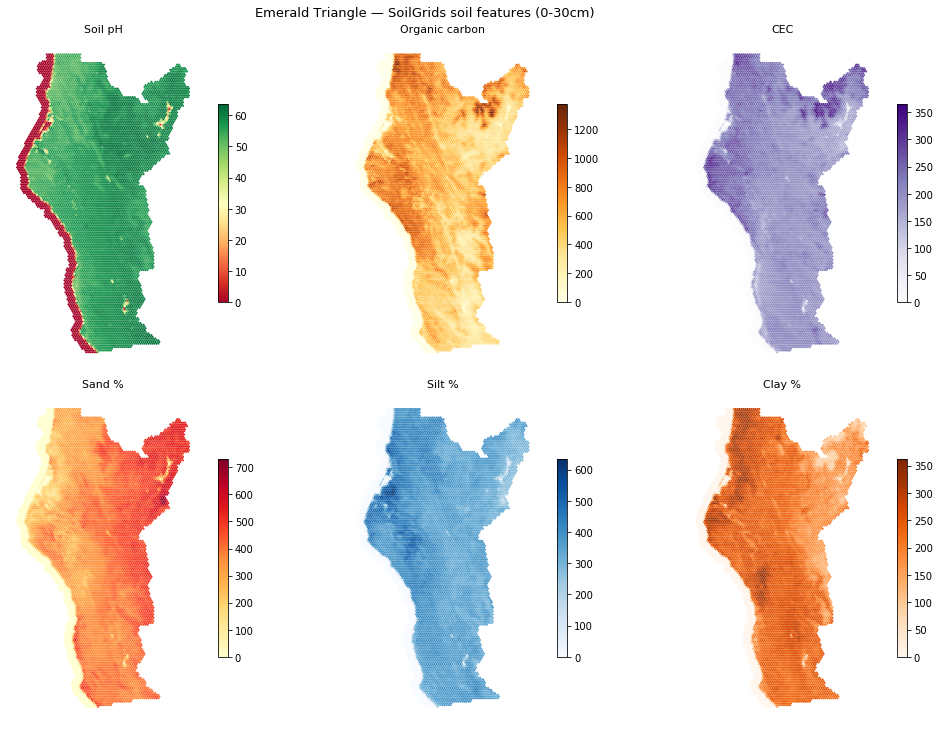

Saved img/06_soil.png


In [6]:
hex_feats = hex_grid.merge(soil_feats, on='cell_id')

plot_vars = [
    ('ph',   'Soil pH',             'RdYlGn'),
    ('soc',  'Organic carbon',      'YlOrBr'),
    ('cec',  'CEC',                 'Purples'),
    ('sand', 'Sand %',              'YlOrRd'),
    ('silt', 'Silt %',              'Blues'),
    ('clay', 'Clay %',              'Oranges'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (col, title, cmap) in zip(axes.flat, plot_vars):
    valid = hex_feats[col].notna()
    hex_feats[valid].plot(column=col, ax=ax, cmap=cmap, legend=True,
                          legend_kwds={'shrink': 0.6}, linewidth=0)
    hex_feats[~valid].plot(ax=ax, color='#ddd', linewidth=0)
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

plt.suptitle('Emerald Triangle — SoilGrids soil features (0-30cm)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../img/06_soil.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/06_soil.png')

## 6. Save

In [7]:
out = PROC / 'soil_features.pkl'
soil_feats.to_pickle(out)
print(f'Saved {out}')
print(f'Shape: {soil_feats.shape}')
print(f'Columns: {soil_feats.columns.tolist()}')
print()
print('Next: 07_assemble_features.ipynb — join all layers into final feature matrix')

Saved ../data/processed/soil_features.pkl
Shape: (8923, 7)
Columns: ['cell_id', 'ph', 'soc', 'sand', 'silt', 'clay', 'cec']

Next: 07_assemble_features.ipynb — join all layers into final feature matrix
